In [8]:

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from solarrpy.calibration import calibrate_window
from solarrpy.sorad import sorad_price, daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, hedged_cf, optimal_Nc, mape, tick

In [ ]:
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()  # H0 is computed internally, and the provided values are not trustworthy

# Bologna Coordinates used in the paper
LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

df_train = df[df['Year'] <= 2013].copy()
cal = calibrate_window(
    df_train,
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': LATITUDE}, train_end_year=2013,
)
print(f'theta={cal.theta:.4f}, alpha={cal.alpha:.4f}, beta={cal.beta:.4f}')

theta=0.8570, alpha=0.0001, beta=0.9129


In [15]:
df_2014 = df[df['Year'] == 2014].sort_values('date').reset_index(drop=True)
print(f'Computing {len(df_2014)} daily SoRad prices for 2014...')
K_arr  = np.array([daily_strike(row['date'], cal) for _, row in df_2014.iterrows()])
R_arr  = df_2014['GHI'].values
cf_u = unhedged_cf(R_arr)                       # raw buyer revenue
cf_b = benchmark_cf(K_arr)                       # seasonal benchmark (black curve)
mape(cf_u, cf_b)

Computing 365 daily SoRad prices for 2014...


29.655731208920702

# Asian SORAD

Simulating 50000 paths for 2014 using exact daily transition...
  Path 0/50000
  Path 10000/50000
  Path 20000/50000
  Path 30000/50000
  Path 40000/50000
Simulation done.

Diagnostic: Monthly strikes, actual averages, payoffs, simulated premiums
Month  1: Strike=1.47, Actual avg=1.31, Payoff=0.016, Premium=0.010
Month  2: Strike=2.30, Actual avg=2.11, Payoff=0.019, Premium=0.008
Month  3: Strike=3.66, Actual avg=3.88, Payoff=0.000, Premium=0.021
Month  4: Strike=5.33, Actual avg=4.84, Payoff=0.049, Premium=0.051
Month  5: Strike=6.75, Actual avg=6.08, Payoff=0.067, Premium=0.068
Month  6: Strike=7.48, Actual avg=6.71, Payoff=0.077, Premium=0.090
Month  7: Strike=7.30, Actual avg=5.92, Payoff=0.138, Premium=0.030
Month  8: Strike=6.28, Actual avg=5.73, Payoff=0.055, Premium=0.034
Month  9: Strike=4.74, Actual avg=4.13, Payoff=0.061, Premium=0.031
Month 10: Strike=3.08, Actual avg=3.13, Payoff=0.000, Premium=0.040
Month 11: Strike=1.83, Actual avg=1.35, Payoff=0.048, Premium=0.026
Month

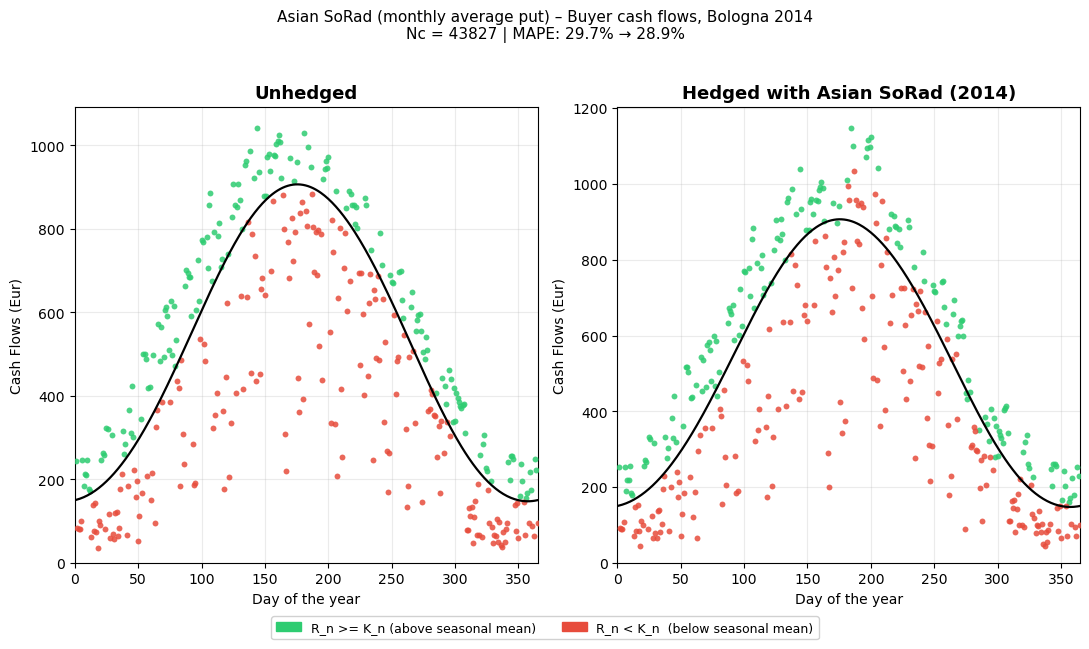


Plot saved as ../results/Figure_ASoRad_2014_buyer_cashflows.png
All gate checks passed.


In [13]:
# =============================================================================
# Asian SoRad (ASoRad) – Monthly average put hedging (Monte Carlo)
# Uses the calibrated cal object (must have clearsky_model, seasonal_mean_model, etc.)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from solarrpy.sorad import daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, mape, tick
from solarrpy.forecastDensity import clearsky_at, seasonal_mean_Y_at, R_to_Y, Y_to_R
from solarrpy.radiationModel_internals import integral_sigma_numeric, integral_sigma2_formula

# -----------------------------------------------------------------------------
# 1. Precompute daily values for the target year
# -----------------------------------------------------------------------------
year = 2014
n_days = 365 + (1 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 0)
dates = pd.date_range(f'{year}-01-01', periods=n_days, freq='D')

# Deterministic series using package functions
C_t = np.array([clearsky_at(d, cal) for d in dates])
Ybar_t = np.array([seasonal_mean_Y_at(d, cal) for d in dates])

omega = 2 * np.pi / 365
t_days = np.arange(1, n_days + 1)
sigma_bar_t = np.sqrt(cal.c[0] + cal.c[1] * np.sin(omega * t_days) + cal.c[2] * np.cos(omega * t_days))

# Monthly mixture parameters
monthly_df = cal.monthly_mixture.set_index('Month')
p_month = monthly_df['p'].values
mu0_month = monthly_df['mu0'].values
mu1_month = monthly_df['mu1'].values
sigma0_month = monthly_df['sd0'].values
sigma1_month = monthly_df['sd1'].values

# Initial Y on day before year start
prev_date = pd.Timestamp(f'{year-1}-12-31')
prev_R = df[df['date'] == prev_date]['GHI'].values[0]
C_prev = clearsky_at(prev_date, cal)
Y_prev = R_to_Y(prev_R, C_prev, cal.alpha, cal.beta)

# -----------------------------------------------------------------------------
# 2. Precompute I and J integrals for each day
# -----------------------------------------------------------------------------
int_I = integral_sigma_numeric(cal.theta, cal.c)
int_J = integral_sigma2_formula(cal.theta, cal.gamma)
ns = dates.dayofyear.values.astype(float)
I_daily = int_I(ns - 1, ns, ns).ravel()
J_daily = int_J(ns - 1, ns, ns).ravel()

# -----------------------------------------------------------------------------
# 3. Exact Monte Carlo simulation
# -----------------------------------------------------------------------------
np.random.seed(12345)
n_sim = 50000   # reduce to 10000 for a quick test
print(f"Simulating {n_sim} paths for {year} using exact daily transition...")
all_R = np.zeros((n_sim, n_days))
for sim in range(n_sim):
    if sim % 10000 == 0:
        print(f"  Path {sim}/{n_sim}")
    Y = np.zeros(n_days)
    Y_curr = Y_prev
    for i in range(n_days):
        month_idx = dates[i].month - 1
        B = np.random.binomial(1, p_month[month_idx])          # 1 = cloudy
        mu_B = mu1_month[month_idx] if B else mu0_month[month_idx]
        sigma_B = sigma1_month[month_idx] if B else sigma0_month[month_idx]
        if i == 0:
            prev_day = dates[0] - pd.Timedelta(days=1)
            Ybar_curr = seasonal_mean_Y_at(prev_day, cal)
        else:
            Ybar_curr = Ybar_t[i-1]
        Ybar_next = Ybar_t[i]
        Y_next = (Ybar_next
                  + (Y_curr - Ybar_curr) * np.exp(-cal.theta)
                  + mu_B * I_daily[i]
                  + sigma_B * np.sqrt(J_daily[i]) * np.random.normal())
        Y[i] = Y_next
        Y_curr = Y_next
    all_R[sim] = np.array([Y_to_R(y, C_t[i], cal.alpha, cal.beta) for i, y in enumerate(Y)])
print("Simulation done.")

# -----------------------------------------------------------------------------
# 4. Daily strikes and actual GHI for the year
# -----------------------------------------------------------------------------
df_year = df[df['Year'] == year].sort_values('date').reset_index(drop=True)
R_actual = df_year['GHI'].values
days_idx = np.arange(1, n_days + 1)
K_daily = np.array([daily_strike(row['date'], cal) for _, row in df_year.iterrows()])

# -----------------------------------------------------------------------------
# 5. Monthly Asian puts
# -----------------------------------------------------------------------------
month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_ends   = [31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
if n_days == 366:
    for i in range(2, len(month_starts)):
        month_starts[i] += 1
        month_ends[i] += 1
months = list(zip(month_starts, month_ends))

monthly_strikes = []
monthly_prices = []
actual_monthly_payoff = []

print("\nDiagnostic: Monthly strikes, actual averages, payoffs, simulated premiums")
for (s, e) in months:
    days_in_month = np.arange(s, min(e, n_days))
    if len(days_in_month) == 0:
        continue
    K_month = np.mean(K_daily[days_in_month])
    monthly_strikes.append(K_month)
    avg_R_per_path = np.mean(all_R[:, days_in_month], axis=1)
    payoff_per_path = tick * np.maximum(K_month - avg_R_per_path, 0)
    monthly_prices.append(np.mean(payoff_per_path))
    avg_R_actual = np.mean(R_actual[days_in_month])
    actual_pay = tick * max(K_month - avg_R_actual, 0)
    actual_monthly_payoff.append(actual_pay)
    print(f"Month {len(monthly_strikes):2d}: Strike={K_month:.2f}, Actual avg={avg_R_actual:.2f}, Payoff={actual_pay:.3f}, Premium={monthly_prices[-1]:.3f}")

# -----------------------------------------------------------------------------
# 6. Distribute monthly premium and payoff equally over days
# -----------------------------------------------------------------------------
daily_premium = np.zeros(n_days)
daily_payoff = np.zeros(n_days)
for idx, ((s, e), prem) in enumerate(zip(months, monthly_prices)):
    days_in_month = np.arange(s, min(e, n_days))
    daily_premium[days_in_month] = prem / len(days_in_month)
    daily_payoff[days_in_month] = actual_monthly_payoff[idx] / len(days_in_month)

# -----------------------------------------------------------------------------
# 7. Optimal number of contracts (global Nc)
# -----------------------------------------------------------------------------
cf_u = unhedged_cf(R_actual)
cf_bench = benchmark_cf(K_daily)
diff = cf_u - cf_bench
delta = daily_payoff - daily_premium
Nc_opt = -np.sum(diff * delta) / np.sum(delta**2)
if Nc_opt < 0:
    Nc_opt = 0
print(f"\nOptimal number of Asian contracts (per month): {Nc_opt:.1f}")

# -----------------------------------------------------------------------------
# 8. Hedged cash flows and performance metrics
# -----------------------------------------------------------------------------
cf_hedged = cf_u + Nc_opt * delta
mape_u = mape(cf_u, cf_bench)
mape_h = mape(cf_hedged, cf_bench)
var_u = np.var(cf_u - cf_bench)
var_h = np.var(cf_hedged - cf_bench)

print(f"\n=== Asian SoRad Results for {year} ===")
print(f"MAPE unhedged = {mape_u:.2f}%")
print(f"MAPE hedged   = {mape_h:.2f}%")
print(f"Variance reduction: {100*(1 - var_h/var_u):.1f}%")

# -----------------------------------------------------------------------------
# 9. Plot (same style as Figure 4)
# -----------------------------------------------------------------------------
above = R_actual >= K_daily
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='R_n >= K_n (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='R_n < K_n  (below seasonal mean)'),
]

dates_dense = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')
K_dense = np.array([daily_strike(d, cal) for d in dates_dense])
cfb_dense = benchmark_cf(K_dense)
days_dense = np.arange(1, len(dates_dense) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, cf_vals, title in [(axes[0], cf_u, 'Unhedged'),
                           (axes[1], cf_hedged, f'Hedged with Asian SoRad ({year})')]:
    ax.scatter(days_idx[above],  cf_vals[above],  s=18, color='#2ecc71', alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(days_idx[~above], cf_vals[~above], s=18, color='#e74c3c', alpha=0.85, zorder=3, linewidths=0)
    ax.plot(days_dense, cfb_dense, 'k-', lw=1.6, zorder=4)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Day of the year', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(0, 365)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Asian SoRad (monthly average put) – Buyer cash flows, Bologna {year}\n'
    f'Nc = {Nc_opt:.0f} | MAPE: {mape_u:.1f}% → {mape_h:.1f}%',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(f'../results/Figure_ASoRad_{year}_buyer_cashflows.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved as ../results/Figure_ASoRad_{year}_buyer_cashflows.png")

# -----------------------------------------------------------------------------
# 10. Gate checks
# -----------------------------------------------------------------------------
assert cf_hedged.min() >= 0, "Negative hedged cash flow"
assert mape_h < mape_u, "Hedge did not reduce MAPE"
assert var_h < var_u, "Hedge did not reduce variance"
print("All gate checks passed.")